In [84]:
# Enable autoreload of imported modules

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [85]:
import pandas as pd
from pathlib import Path
import yaml
import spacy

def load_config(path):
    """
    Load event config file and data.

    Returns: Config `cfg` and DataFrame `df`.
    """
    config_file = path
    cfg = yaml.safe_load(Path(config_file).read_text(encoding='utf-8')).get('event', {})

    # Normalize keywords
    nlp = spacy.load("en_core_web_lg")
    doc = nlp(" ".join(cfg["keywords"]))
    cfg['keywords'] = [t.lemma_ for t in doc]

    # Check if cleaned file exists
    cleaned_path = Path(cfg['input_file'].replace('/raw/', '/clean/'))
    if cleaned_path.exists():
        print(f"Reading cleaned file: {cleaned_path}")
        cfg['cleaned_file'] = cleaned_path
        df = pd.read_csv(cleaned_path)
    else: 
        print(f"Reading raw file: {cfg['input_file']}")
        df = pd.read_csv(cfg['input_file'])

    return cfg, df

In [86]:
### Timing decorator
import time

def timing(func):
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        print(f"{func.__name__} took {end - start:.4f} seconds")
        return result
    return wrapper


In [87]:
from preprocessing.normalize_text import normalize_text_series

def normalize_texts(df, batch_size=50, n_process=10):
    """
    Create clean text columns for 'title', 'text' and 'first_para'.
    """

    if 'title' in df:
        df['title_clean'] = normalize_text_series(df['title'], 
                                                  batch_size=batch_size, 
                                                  n_process=n_process)
    if 'text' in df:
        df['text_clean'] = normalize_text_series(df['text'], 
                                                  batch_size=batch_size, 
                                                  n_process=n_process)
    if 'first_para' in df:
        df['first_para_clean'] = normalize_text_series(df['first_para'], 
                                                  batch_size=batch_size, 
                                                  n_process=n_process)
    
    return df

In [88]:
from preprocessing.tfidf_dedupe import dedupe_tfidf_cosine

@timing
def dedupe_texts(df, text_col):
    """
    Dedupe entries in `df` with nearly identical values in `text_col`. Keeps the longest text by default.
    """
    threshold = 0.9
    min_df = 1  # min doc frequency
    ngram_min = 1
    ngram_max = 2
    max_features=None
    prefer_longer = True
    block_by_length = True  # compare only to similar length documents
    return_groups = True

    deduped_df, dedupe_report = dedupe_tfidf_cosine(
        df,
        text_col=text_col,
        threshold=threshold,
        min_df=min_df,
        ngram_min=ngram_min,
        ngram_max=ngram_max,
        max_features=max_features,
        prefer_longer=prefer_longer,
        block_by_length=block_by_length,
        return_groups=return_groups,
    )

    return deduped_df, dedupe_report

In [89]:
config_file = Path("config/elpaso.yaml")
cfg, df = load_config(config_file)

xlim = (-7,30)

root_dir = Path(".").absolute()

Reading cleaned file: data/event_data/clean/2019_elpaso_tx.csv


In [90]:
# Prepare output dir

save_output = True  # Save output files

output_dir = root_dir.joinpath(f"output/{config_file.stem}")
print(f"Output dir: {output_dir}")

if save_output:  # Make output_dir
    output_dir.mkdir(parents=True, exist_ok=True)

report = dict()
# report['cfg'] = cfg


Output dir: /data/jupyter/event_dynamics/HSMS_LUGOS/output/elpaso


In [91]:

# If we did not find a cleaned file, cleanup text
if not 'cleaned_file' in cfg:
    # Normalize text columns
    df = normalize_texts(df)
    # Dedupe DF
    df, report_text = dedupe_texts(df, text_col='text_clean')
    df, report_title = dedupe_texts(df, text_col='title_clean')
    df, report_para = dedupe_texts(df, text_col='first_para')

    print(f"Documents after deduping: {len(df)}")

report["docs_clean"] = len(df)

In [92]:
# Make datetime indices and filters
df.index = pd.DatetimeIndex(pd.to_datetime(df["date"], format="%Y%m%d"))
df = df.sort_index()
df = df[cfg['start_date']: cfg['end_date']]

# Drop datetime indices
df = df.reset_index(drop=True)
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")
df = df.sort_values("date")
# dates = df["date"]


In [93]:
# Normalize time (t=-7 to t=+30), aggregate per day
from typing import Tuple
from datetime import datetime

def normalize_time(df: pd.DataFrame,
                   date_col: str = 'date',
                   onset_date: datetime = None):
    """
    Normalize date column and convert it to discrete time indices.
    """
    if onset_date is None:
        print(f"Must inform onset_date!")
        exit(1)
    onset_date = pd.to_datetime(onset_date)
    
    norm_time = (df[date_col] - onset_date).dt.days
    return norm_time

df['norm_date'] = normalize_time(df, 'date', cfg['onset_date'])
df['norm_date']

0        -8
252      -8
251      -8
250      -8
249      -8
         ..
12306    31
12305    31
12304    31
12313    31
12564    31
Name: norm_date, Length: 12565, dtype: int64

In [94]:
texts = (df['title_clean'].fillna("") + ". " + df['first_para_clean'].fillna(""))  # .tolist()
# texts = (df['title_clean'].fillna(""))  # .tolist()



In [95]:
### Count documents containing seed keywords

import re
from collections import Counter

# Get seed word list from config and normalize to match cleaned texts
seed_words_raw = cfg.get('keywords', [])
# Normalize: lowercase, strip non-alpha (same style as clean_text_regex)
seed_words = []
for w in seed_words_raw:
    w_norm = re.sub(r'[^a-z\s]', '', str(w).lower()).strip()
    if w_norm:
        seed_words.append(w_norm)

seed_words = sorted(set(seed_words))

# 3) Tokenize each cleaned text into a list of words (whitespace split)
def tokenize_cleaned(s: str):
    # 'texts' are already cleaned (lowercase, non-alpha removed, stopwords removed)
    return s.split()

seed_set = set(seed_words)

doc_seed_hits_detail = []
doc_seed_hits_count = []
doc_seed_hits_unique = []

for s in texts:
    toks = tokenize_cleaned(s)
    # Count only tokens that are seeds
    hits = [t for t in toks if t in seed_set]
    cnt = Counter(hits)
    doc_seed_hits_detail.append(cnt)              # Counter dict per doc
    doc_seed_hits_count.append(sum(cnt.values())) # total matches
    doc_seed_hits_unique.append(len(cnt.keys()))  # unique seeds matched

# Attach to df (aligned by row)
df["seed_hits_count"] = doc_seed_hits_count
df["seed_hits_unique"] = doc_seed_hits_unique
# To store a JSON-friendly form of the dict:
df["seed_hits_detail"] = [dict(c) for c in doc_seed_hits_detail]

print(f"Documents with >= 1 seed hit: {(df['seed_hits_count']>0).sum()}/{len(df)}")

Documents with >= 1 seed hit: 3312/12565


In [96]:
import matplotlib.pyplot as plt

def plot_onset_line(ymin=-1, ymax=1, linestyles="-", colors="black", linewidth=1, label="Event onset", ax=None):
    plt.autoscale(False)  # Set autoscale before drawing vertical line

    if ax is None:
        plt.vlines((0), ymin=ymin, ymax=ymax, linestyles=linestyles, colors=colors, linewidths=linewidth, label=label)
    else:
        ax.vlines((0), ymin=ymin, ymax=ymax, linestyles=linestyles, colors=colors, linewidths=linewidth, linewidth=1)


/data/jupyter/event_dynamics/HSMS_LUGOS


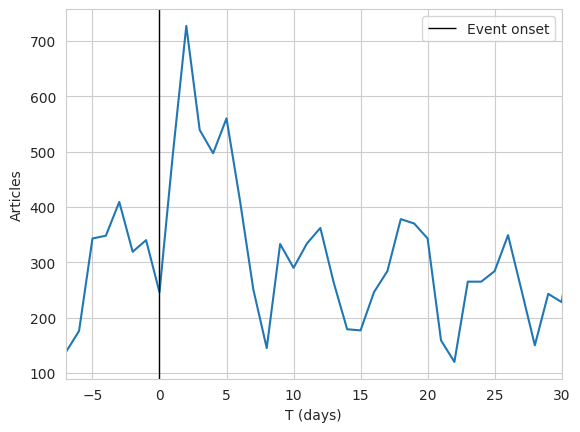

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
# articles_per_day = df.resample('1D', on="date")['GlobalEventID'].count().plot();
articles_per_day = df.groupby('norm_date')['GlobalEventID'].count();

plt.clf()
fig = sns.lineplot(data=articles_per_day);
plt.xlabel("T (days)")
plt.ylabel("Articles")
plt.xlim(*xlim)
plot_onset_line(0, max(articles_per_day)*1.1)
# plt.vlines((0), ymin=min(articles_per_day), ymax=max(articles_per_day+5), linestyles='--', colors='black', linewidth=1, label='Event onset');
plt.legend();


if save_output:
    print(Path(".").absolute())
    plt.savefig(output_dir.joinpath("articles_per_day.pdf"))
    

In [98]:
from sentence_transformers import SentenceTransformer

# load embeddings
model_name = "sentence-transformers/all-MiniLM-L6-v2"
embedder = SentenceTransformer(model_name)
embeddings = embedder.encode(texts, batch_size=128, show_progress_bar=True)

Batches:   0%|          | 0/99 [00:00<?, ?it/s]

In [99]:
## Filter only documents with some seed hit


seed_mask = df['seed_hits_count'] >= 2
print(f"Documents in: {seed_mask.sum()} | out: {(1-seed_mask).sum()}")

## Before we drop documents from the dataset, let us find those with high SBERT similarity to seed-hit docs

# Compute the nearest neighbors of each non-seed documents and flip it if the majority is in-topic.
from analysis.topic_modeling import knn_majority_flip

new_mask, details = knn_majority_flip(embeddings, seed_mask)

print(f"Before join: {seed_mask.sum()}. After join: {new_mask.sum()}")

report['docs_after_join'] = int(new_mask.sum())

Documents in: 2167 | out: 10398
Before join: 2167. After join: 2330


In [100]:
# Split dataframes
import numpy as np


df['row_id'] = np.arange(len(df))
df['is_event'] = new_mask

df_in = df[new_mask]
# texts_in = texts[new_mask].copy().reset_index(drop=True)
texts_in = texts[new_mask]
embeddings_in = embeddings[new_mask]

df_out = df[~new_mask]
texts_out = texts[~new_mask]
embeddings_out = embeddings[~new_mask]



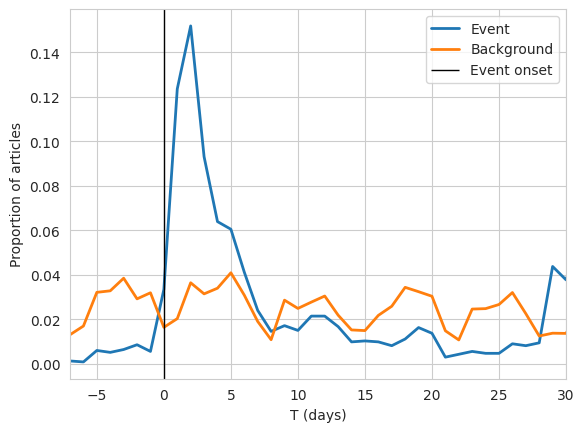

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# dts = sorted(df['norm_date'].unique())
# articles_per_day_in = [len(df_in[df_in['norm_date']==d])/len(df_in) for d in dts]
# articles_per_day_out = [len(df_out[df_out['norm_date']==d])/len(df_out) for d in dts]
articles_per_day_in = df_in['norm_date'].value_counts(normalize=True)
articles_per_day_out = df_out['norm_date'].value_counts(normalize=True)

max_y = max(max(articles_per_day_in), max(articles_per_day_out))


plt.clf();
plt.xlim(*xlim)
sns.lineplot(data=articles_per_day_in, label="Event", lw=2)
sns.lineplot(data=articles_per_day_out, label="Background", lw=2)
# plt.autoscale(False)  # Set autoscale before drawing vertical line
# plt.vlines((0), ymin=0, ymax=1, linestyles='--', colors='black', linewidth=1, label='Event onset')
plot_onset_line(-1, ymax=1)
plt.ylabel("Proportion of articles")
plt.xlabel("T (days)")
plt.legend();

if save_output:
    plt.savefig(output_dir.joinpath("event_articles_per_day.pdf"));


In [102]:
# Centroid functions
from numpy.linalg import norm
import numpy as np


def cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    na, nb = norm(a), norm(b)
    if na == 0 or nb == 0:
        return np.nan
    return 1.0 - float(np.dot(a, b) / (na * nb))



def geometric_median(X, eps=1e-5, max_iter=200):
    # X: (n, d)
    y = X.mean(axis=0)
    for _ in range(max_iter):
        d = np.linalg.norm(X - y, axis=1)
        # Avoid division by zero
        d = np.where(d < eps, eps, d)
        w = 1.0 / d
        y_new = (w[:, None] * X).sum(axis=0) / w.sum()
        if np.linalg.norm(y_new - y) < eps:
            break
        y = y_new
    return y


def compute_daily_centroids(df, embeddings, centroid_method: str = "mean") -> pd.DataFrame:
    """
    Compute the centroids for each day for a given topic dataframe.

    Args:
        df (pd.DataFrame): input topic dataframe.
        embeddings (np.ndarray[float]) : The document embeddings.
        centroid_method (str) : The centroid calculation method {'mean' or 'median'}.
    Returns:
    """
    ## Compute the centroids for each day

    daily_centroids = []
    groups = df.groupby(df["norm_date"])
    for gdate, gdf in groups:
        pos_idx = gdf["row_id"].to_numpy()  # Get row positions in original df
        # Find local positions for embeddings
        local_idx = df.index.get_indexer(gdf.index)        # positions within df_topic    
        emb_day = embeddings[local_idx]  # Get embeddings for this date
        if emb_day.size == 0:
            continue
        if centroid_method == "mean":
            centroid_sbert = emb_day.mean(axis=0)  # Compute centroid
        elif centroid_method == "median":
            centroid_sbert = geometric_median(emb_day)
        else:
            print(f"Invalid centroid_method: {centroid_method}")
            exit(1)
        daily_centroids.append({
            "date_str": gdate,
            "emb": centroid_sbert,
            "date": gdf["date"].min(),
            "n_docs": len(emb_day)
        })


    # Convert to DataFrame and sort chronologically
    cent_df = pd.DataFrame(daily_centroids)
    # Normalize date: if 'date' is an int/string in YYYYMMDD format, convert to datetime
    cent_df["dt"] = cent_df['date_str']
    cent_df = cent_df.sort_values("dt").reset_index(drop=True)

    return cent_df


def smoothen_centroids_and_dist(cent_df: pd.DataFrame) -> pd.DataFrame:
    #  Exponential Moving Average (EMA) smoothing of centroids (vector EMA)
    use_vol_scale = True

    vol_scale = np.percentile(cent_df["n_docs"], 75)  # robust target volume
    base_alpha = 0.20  # Lower = smoother

    ema = []
    prev = None
    for i, row in cent_df.iterrows():
        c = row["emb"]  # numpy 1D vector
        n = row["n_docs"]
        # Adjust alpha per number of documents on that day / cap at [min_alpha, base_alpha]
        if use_vol_scale:
            adj_alpha = base_alpha * min(1.0, n / vol_scale)
            adj_alpha = max(0.05, adj_alpha)  # avoid freezing on small n
        else:
            adj_alpha = base_alpha

        if prev is None:
            s = c.copy()           # initialize EMA with first day's centroid
        else:
            s = adj_alpha * c + (1.0 - adj_alpha) * prev
        ema.append(s)
        prev = s

    cent_df["centroid_ema"] = ema  # attach smoothed centroid


    # Distance between consecutive smoothed centroids (main stability signal)
    dist_smooth = [np.nan]
    for i in range(1, len(cent_df)):
        d = cosine_distance(cent_df.loc[i, "centroid_ema"], cent_df.loc[i-1, "centroid_ema"])
        dist_smooth.append(d)
    cent_df["dist_smooth_to_prev_smooth"] = dist_smooth

    # Distance between raw centroid and previous day's smoothed centroid (outlier sensitivity)
    dist_raw_to_prev_smooth = [np.nan]
    for i in range(1, len(cent_df)):
        d = cosine_distance(cent_df.loc[i, "emb"], cent_df.loc[i-1, "centroid_ema"])
        dist_raw_to_prev_smooth.append(d)
    cent_df["dist_raw_to_prev_smooth"] = dist_raw_to_prev_smooth

    return cent_df

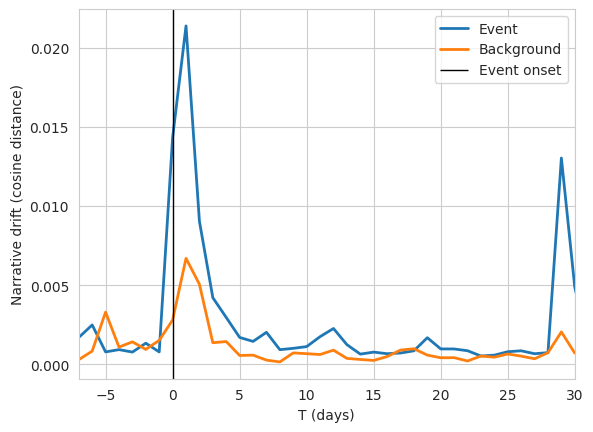

In [103]:
# Retrieve subsets of DataFrame and embeddings
import matplotlib.pyplot as plt

# ## Compute the event centroids for each day
cent_df = compute_daily_centroids(df_in, embeddings_in)
cent_df = smoothen_centroids_and_dist(cent_df)


## Compute background centroids
cent_df_c = compute_daily_centroids(df_out, embeddings_out)
cent_df_c = smoothen_centroids_and_dist(cent_df_c)

## Compute overall centroids for each day
cent_df_all = compute_daily_centroids(df, embeddings)
cent_df_all = smoothen_centroids_and_dist(cent_df_all)


y_col = 'dist_smooth_to_prev_smooth'

plt.clf();
plt.xlim(*xlim)
sns.lineplot(data=cent_df, x='dt', y=y_col, label='Event', lw=2);
# plt.xticks(rotation=45);

sns.lineplot(data=cent_df_c, x='dt', y=y_col, label='Background', lw=2)
# plt.xticks(rotation=45);

plot_onset_line(-1, 1)
plt.legend()
plt.ylabel('Narrative drift (cosine distance)')
plt.xlabel('T (days)');

if save_output:
    plt.savefig(output_dir.joinpath("narrative_drift.pdf"))




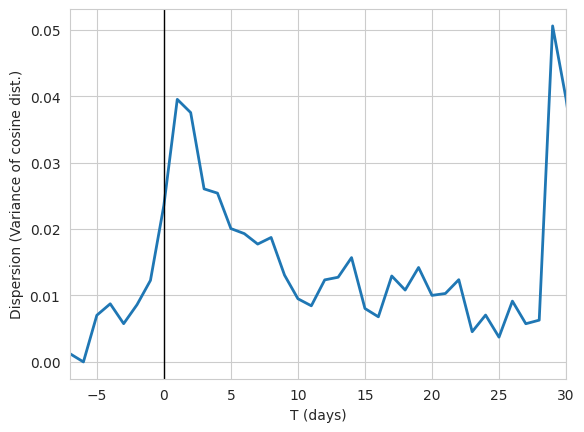

In [104]:
### Plot dispersion

from analysis.dispersion import get_centroid_dispersion_per_day

# Get dispersion scores
dispersion_event = get_centroid_dispersion_per_day(df_in, embeddings_in)
cent_df['dispersion'] = dispersion_event

cent_df_c['dispersion'] = get_centroid_dispersion_per_day(df_out, embeddings_out)
cent_df_all['dispersion'] = get_centroid_dispersion_per_day(df, embeddings)



plt.clf()
sns.lineplot(data=cent_df, x='dt', y='dispersion', linewidth=2)
plt.xlabel("T (days)")
plt.ylabel("Dispersion (Variance of cosine dist.)")
plt.xlim(*xlim)

plot_onset_line(-1, 1)

if save_output:
    plt.savefig(output_dir.joinpath("narrative_dispersion.pdf"))



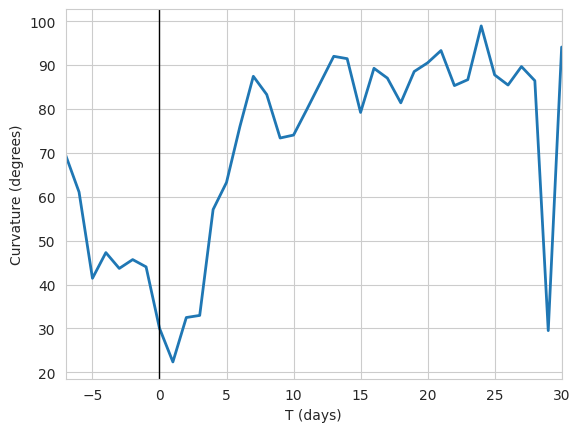

In [105]:
### Get daily curvatures
from analysis.dispersion import compute_curvature

# Get curvatures
curvatures = compute_curvature(cent_df['centroid_ema'], output_unit='degrees')
cent_df['curvature'] = curvatures

cent_df_c['curvature'] = compute_curvature(cent_df_c['centroid_ema'], output_unit='degrees')
cent_df_all['curvature'] = compute_curvature(cent_df_all['centroid_ema'], output_unit='degrees')


plt.clf()
sns.lineplot(data=cent_df, x='dt', y='curvature', linewidth=2)
plt.xlabel("T (days)")
plt.ylabel("Curvature (degrees)")
plt.xlim(*xlim)

plot_onset_line(0, 360)

if save_output:
    plt.savefig(output_dir.joinpath("narrative_curvature.pdf"))

In [106]:
# Compute drift from baseline anchor (t < 0)


def get_drift_from_anchor(cent_df, anchor_emb, centroid_col='centroid_ema'):
    """
    Returns the drift from the anchor using centroids in `cent_df`.
    """

    drifts = cent_df[centroid_col].apply(lambda v: cosine_distance(v, anchor_emb))
    return drifts
    

def get_baseline_drift(cent_df, cent_df_c):
    """
    Return the 
    """
    baseline_anchor = np.mean(cent_df_c['centroid_ema'].iloc[:7], axis=0)
    drifts = get_drift_from_anchor(cent_df, baseline_anchor)
    # We do not want drifts before t=0 (event has not occurred yet)
    cent_df['drift_from_baseline'] = drifts
    before_event = cent_df['dt'] < 0
    cent_df['drift_from_baseline'].mask(before_event, np.nan, inplace=True)
    print(cent_df[['dt', 'drift_from_baseline']])
    return cent_df



In [107]:
cent_df = get_baseline_drift(cent_df, cent_df_all)

cent_df_c = get_baseline_drift(cent_df_c, cent_df_all)

cent_df_all = get_baseline_drift(cent_df_all, cent_df_all)

    dt  drift_from_baseline
0   -8                  NaN
1   -7                  NaN
2   -6                  NaN
3   -5                  NaN
4   -4                  NaN
5   -3                  NaN
6   -2                  NaN
7   -1                  NaN
8    0             0.163468
9    1             0.124715
10   2             0.111753
11   3             0.100964
12   4             0.096052
13   5             0.087439
14   6             0.079295
15   7             0.075389
16   8             0.076544
17   9             0.071857
18  10             0.065034
19  11             0.056671
20  12             0.049538
21  13             0.046206
22  14             0.047478
23  15             0.043714
24  16             0.042188
25  17             0.039215
26  18             0.038397
27  19             0.034863
28  20             0.033372
29  21             0.032168
30  22             0.032621
31  23             0.032434
32  24             0.031915
33  25             0.031465
34  26             0

In [108]:
### Dump report and daily dataframe
import json

print(report)
if save_output:
    cent_df.to_csv(output_dir.joinpath("daily_event.csv"), index=None)
    cent_df_c.to_csv(output_dir.joinpath("daily_background.csv"), index=None)
    cent_df_all.to_csv(output_dir.joinpath("daily_overall.csv"), index=None)
    with open(output_dir.joinpath("report.json"), "w") as fout:
        fout.write(json.dumps(report))

    print("Saved all output!")

{'docs_clean': 12825, 'docs_after_join': 2330}
Saved all output!


In [109]:
from analysis.topic_modeling import init_bertopic_model
import numpy as np
from analysis.topic_modeling import reassign_outliers

topic_model = init_bertopic_model(cfg['keywords'], seed_multiplier=1.0)
topics, probs = topic_model.fit_transform(texts_in.reset_index(drop=True), embeddings_in)

topic_info = topic_model.get_topic_info()

df_in['topic'] = topics

# Reassign outliers

reassign_outliers(df_in, probs, reassign_prob=0.25)




Outliers before reassign: 923
Outliers after reassign: 513


In [110]:
# # # === Analyze topic coverage of seed hits
from analysis.topic_modeling import get_topic_coverage_of_seeds

topic_seed_coverage = get_topic_coverage_of_seeds(df_in, topic_model, cfg['keywords'])

if save_output:
    topic_seed_coverage.to_csv(output_dir.joinpath("topic_coverage.csv"), index=None)

In [111]:
from analysis.topic_modeling import daily_topic_purity

topic_purity = daily_topic_purity(df_in)


In [112]:
from analysis.topic_modeling import daily_topic_counts

topic_counts = daily_topic_counts(df_in)

# sns.lineplot(data=topic_counts, x="day", y="n_docs_topic_day", hue="topic");

In [113]:
## Analyze subtopic lexical coherence using topic word overlap

from analysis.subtopic import day_lexical_coherence

lexical_coherence = day_lexical_coherence(df_in, topic_model)


In [114]:
# Calculate smoothed topic centroids

def compute_daily_topic_centroids(df, embeddings, centroid_method: str = "mean") -> pd.DataFrame:
    """
    Compute the centroids for each day for a given topic dataframe.

    Args:
        df (pd.DataFrame): input topic dataframe.
        embeddings (np.ndarray[float]) : The document embeddings.
        centroid_method (str) : The centroid calculation method {'mean' or 'median'}.
    Returns:
    """
    ## Compute the centroids for each day

    daily_centroids = []
    groups = df.groupby(["norm_date", "topic"])
    for gidx, gdf in groups:
        day, topic = gidx
        if topic == -1:  # Skip this topic
            continue
        # Find local positions for embeddings
        local_idx = df.index.get_indexer(gdf.index)        # positions within df_topic    
        emb_day = embeddings[local_idx]  # Get embeddings for this date
        if emb_day.size == 0:
            continue
        if centroid_method == "mean":
            centroid_sbert = emb_day.mean(axis=0)  # Compute centroid
        elif centroid_method == "median":
            centroid_sbert = geometric_median(emb_day)
        else:
            print(f"Invalid centroid_method: {centroid_method}")
            exit(1)
        daily_centroids.append({
            "day": day,
            "topic": topic,
            "emb": centroid_sbert,
            "date": gdf["date"].min(),
            "n_docs": len(emb_day)
        })


    # Convert to DataFrame and sort chronologically
    cent_df = pd.DataFrame(daily_centroids)
    # Normalize date: if 'date' is an int/string in YYYYMMDD format, convert to datetime
    cent_df["dt"] = cent_df['day']
    cent_df = cent_df.sort_values("dt").reset_index(drop=True)

    return cent_df

In [115]:
from analysis.dispersion import smoothen_centroids_and_dist_per_topic
cent_topics = compute_daily_topic_centroids(df_in, embeddings_in)
cent_topics = smoothen_centroids_and_dist_per_topic(cent_topics)


In [116]:
# Analyzing subtopic coherence with embeddings
from analysis.subtopic import subtopic_coherence_embedding

coherence_per_topic, coherence_agg = subtopic_coherence_embedding(df_in, embeddings_in)



In [117]:

topics_daily = topic_counts
topics_daily = topics_daily.merge(coherence_per_topic, 
                                left_on=['day', 'topic'], 
                                right_on=['day', 'topic'],
                                how='left')

topics_daily = topics_daily.merge(cent_topics,
                                  left_on=["day", "topic"],
                                  right_on=["day", "topic"],
                                  how="left")

if save_output:
    topics_daily.to_csv(output_dir.joinpath("topics_daily.csv"), index=None)

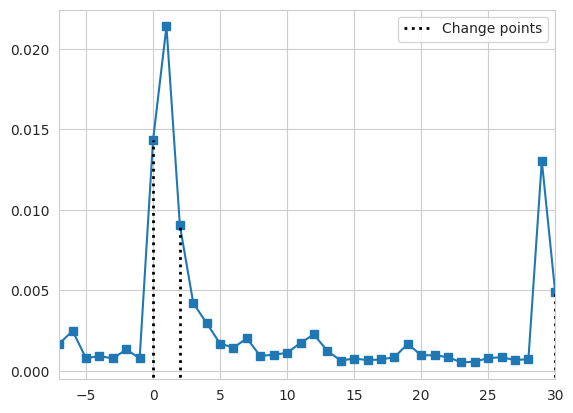

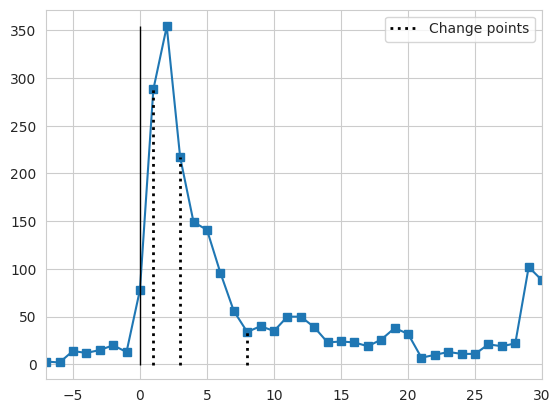

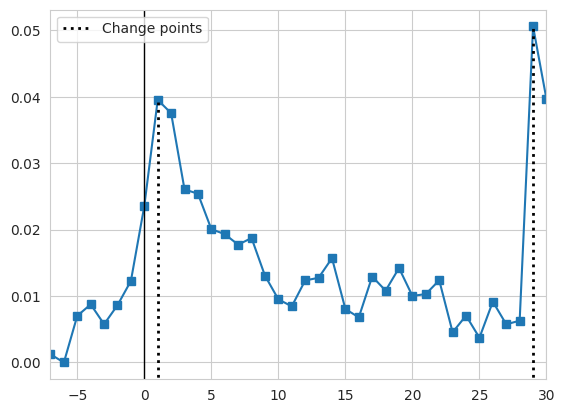

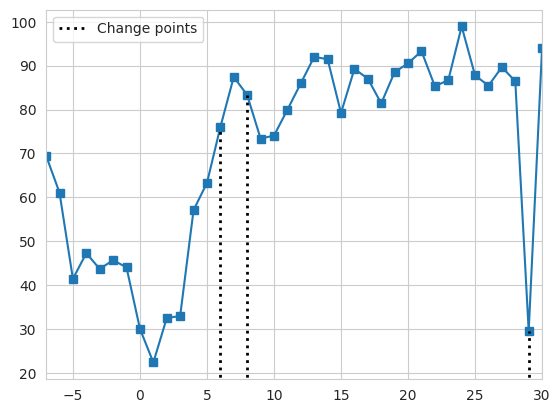

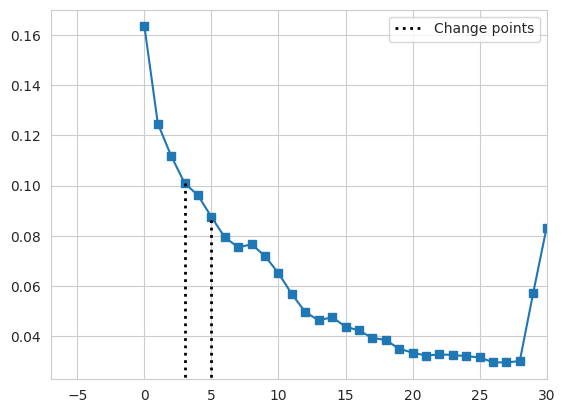

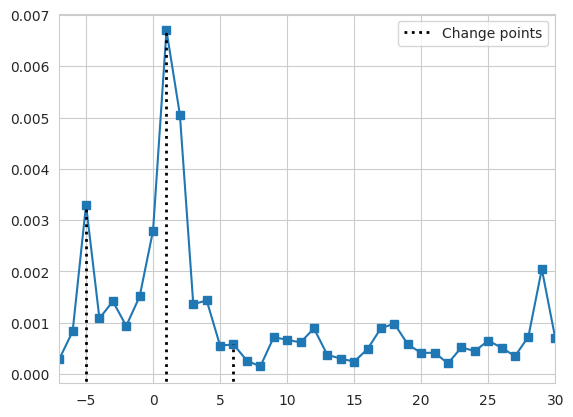

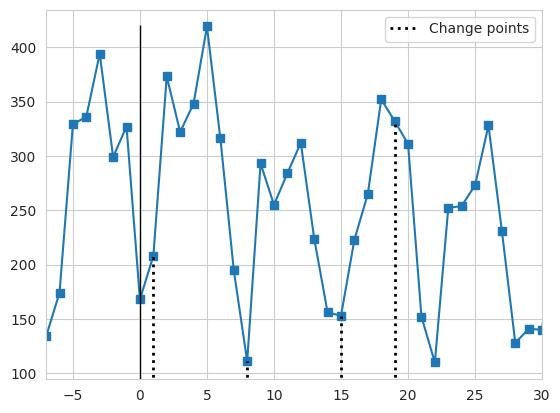

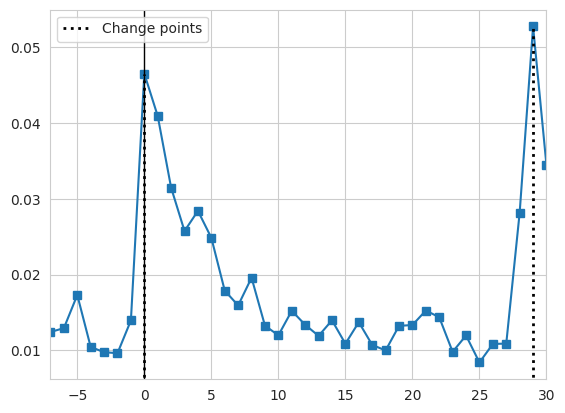

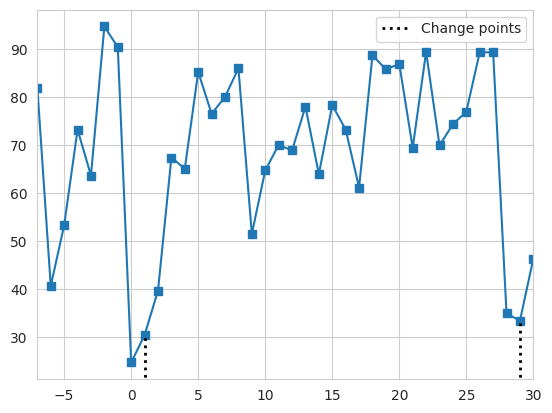

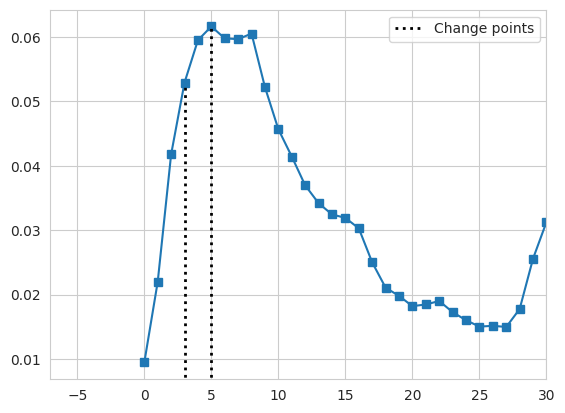

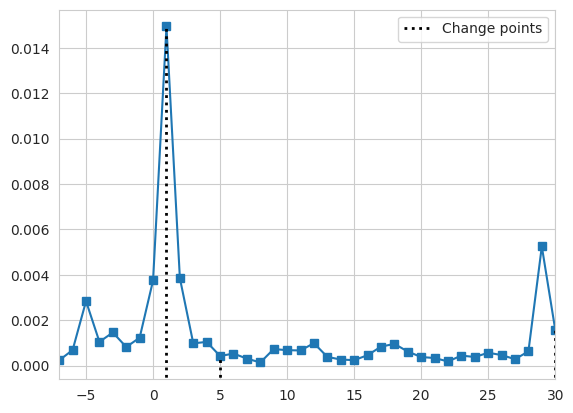

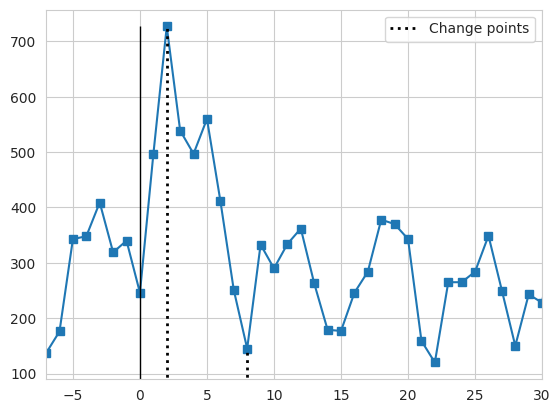

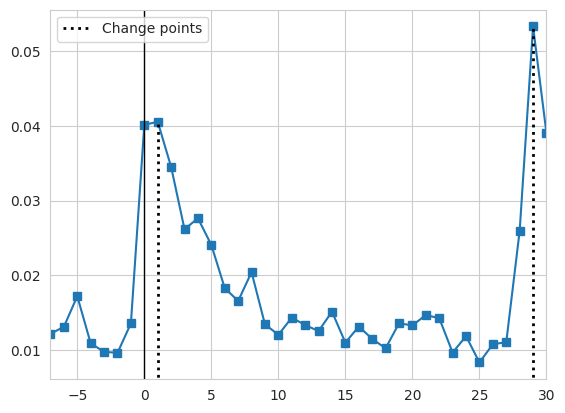

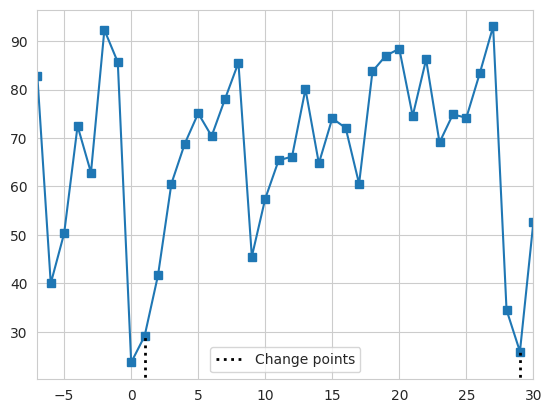

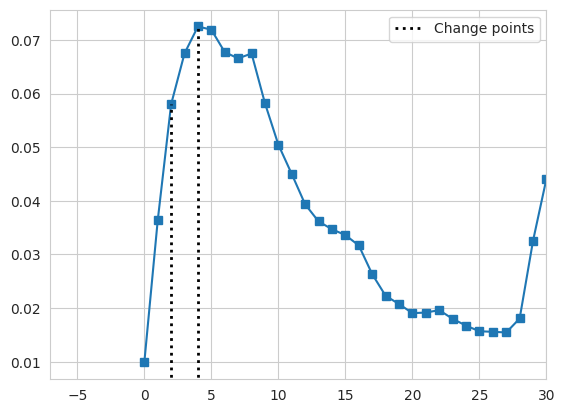

In [118]:
### Perform changepoint detection of univariate signals

from analysis.changepoint import percentile_bursts, preprocess_signal, binary_segmentation_mean, detect_cp_abs_dev




def get_changepoints(cent_df, preprocess_input=True, signals=None, q=90, window=5, k=2):
    cp_results = list()
    if signals is None:
        signals = ["dist_smooth_to_prev_smooth", "n_docs", "dispersion", "curvature", "drift_from_baseline"]

    for signal_col in signals:
        if preprocess_input:
            x_signal = preprocess_signal(cent_df[signal_col])
        else:
            x_signal = cent_df[signal_col]
            
        cp, rscore, loc, thr = percentile_bursts(x_signal, 
                                            q=q, 
                                            window=window,
                                            location="mad",
                                            k=k,
                                            min_gap=2)
        cp_shifted = np.array(cp)+min(cent_df['dt'])  # Shift change points to origin
        # plt.clf()
        # # ax = sns.lineplot(data=cent_df, x="dt", y=signal_col, linewidth=1);
        # fig, ax = plt.subplots()
        # ax.plot(cent_df['dt'], x_signal, linewidth=2, marker='d');
        # plot_onset_line(0, max(x_signal)+1, ax=ax)
        # plt.legend();
        # axes.append(ax)
    
        # plt.plot(cent_df['dt'], loc)
        # # plt.plot(cent_df['dt'], np.ones(len(x_signal))*np.median(x_signal), linestyle='--')
        # plt.xlim(*xlim)

        # # plt.autoscale(False)  # Set autoscale before drawing vertical line
        # # plt.vlines(0, ymin=0, ymax=max(x_signal+1), linestyles='--', colors='black', linewidth=1, label='Event onset');
        # plot_onset_line(0, max(x_signal)+1)
        # plt.vlines(cp_shifted, ymin=0, ymax=x_signal[cp], linestyles=':', colors='black', linewidth=2, label='Change points');
        # plt.legend();

        cp_results.append(
            {"signal": signal_col,
            "cp": cp,
            "cp_shifted": cp_shifted,
            "thr": thr,
            "response_scores": rscore.tolist()}
        )
    
    return pd.DataFrame(cp_results)


def plot_signal_cp(x, y, cp, cp_shifted, ax):
    ax.plot(x, y, marker='s');
    ax.set_xlim(*xlim)
    plot_onset_line(-1, max(y)+1, ax=ax);
    ax.vlines(cp_shifted, ymin=-1, ymax=y[cp], linestyles=":", colors="black", linewidth=2, label="Change points");
    ax.legend();
    

signals = ["dist_smooth_to_prev_smooth", "n_docs", "dispersion", "curvature", "drift_from_baseline"]
cp_results = list()
for name, cdf in zip(["event", "background", "overall"], [cent_df, cent_df_c, cent_df_all]):
    res = get_changepoints(cdf, signals=signals)
    cp_results.append(res)

    for row in res.itertuples():
        fig, ax = plt.subplots()
        plot_signal_cp(cdf['dt'], cdf[row.signal], row.cp, row.cp_shifted, ax=ax)

        if save_output:
            wo_dir = output_dir.joinpath("changepoint", name)
            wo_dir.mkdir(exist_ok=True, parents=True)
            fig.savefig(wo_dir.joinpath(f"cp_{name}_{row.signal}.pdf"))

    if save_output:
        wo_dir = output_dir.joinpath("changepoint", name)
        wo_dir.mkdir(exist_ok=True, parents=True)
        res.to_csv(wo_dir.joinpath(f"cp_{name}.csv"), index=None)



In [119]:
from analysis.topic_modeling import get_daily_word_scores

word_dfs_in = get_daily_word_scores(df_in, day_col='norm_date', text_col='first_para_clean', n_top=300, ngram_range=(1,3))
word_dfs_bg = get_daily_word_scores(df_out, day_col='norm_date', text_col='first_para_clean', n_top=300, ngram_range=(1,3))
word_dfs_all = get_daily_word_scores(df, day_col='norm_date', text_col='first_para_clean', n_top=300, ngram_range=(1,3))

if save_output:

    for grp, dfs in zip(["event", "background", "all"], [word_dfs_in, word_dfs_bg, word_dfs_all]):
        wo_dir = Path(output_dir.joinpath("words_counts", grp))
        wo_dir.mkdir(exist_ok=True, parents=True)
        for d in dfs:
            d.to_csv(wo_dir.joinpath(f"day_{d['day'][0]}.csv"), index=None)



In [120]:
# Load aggregate event info

event_info_file = output_dir.joinpath("agg_codes.csv")

event_info = pd.read_csv(event_info_file)

event_info.head(10)

,SOURCEURL,Actor1Code,Actor1Name,Actor1EthnicCode,Actor2Code,Actor2Name,EventCode,EventRootCode,EventBaseCode,GoldsteinScale,AvgTone
0,http://1049maxcountry.com/abc_politics/key-que...,"[nan, 'GOV']","[nan, 'AUTHORITIES']","[nan, nan]","['RAD', nan]","['EXTREMIST', nan]","[51, 12]","[5, 1]","[51, 12]","[3.4, -0.4]","[-9.36220925767911, -8.16165078224603]"
1,http://1220thelegends.com/at-19-years-gone-ste...,['USA'],['UNITED STATES'],[nan],[nan],[nan],[17],[1],[17],[0.0],[2.22378689197911]
2,http://1220thelegends.com/florida-white-suprem...,"['USA', 'USA']","['UNITED STATES', 'FLORIDA']","[nan, nan]","[nan, nan]","[nan, nan]","[193, 193]","[19, 19]","[193, 193]","[-10.0, -10.0]","[-12.9113924050633, -12.9113924050633]"
3,http://1220thelegends.com/texas-teen-arrested-...,[nan],[nan],[nan],['GTM'],['GUATEMALA'],[43],[4],[43],[2.8],[-7.09812108559499]
4,http://1220thelegends.com/thousands-expected-t...,['USA'],['TEXAS'],[nan],['UAF'],['GUNMAN'],[193],[19],[193],[-10.0],[-2.13125959164082]
5,http://180dfo.com/2019/08/republicans-face-a-m...,"[nan, 'LEG', 'LEG', 'USA']","[nan, 'CONGRESS', 'CONGRESS', 'UNITED STATES']","[nan, nan, nan, nan]","['LEG', nan, 'USA', 'LEG']","['CONGRESS', nan, 'UNITED STATES', 'CONGRESS']","[36, 36, 36, 36]","[3, 3, 3, 3]","[36, 36, 36, 36]","[4.0, 4.0, 4.0, 4.0]","[-0.94339622641509, -0.94339622641509, -0.9433..."
6,http://7thspace.com/headlines/919717/uta_and_l...,[nan],[nan],[nan],['BUS'],['COMPANY'],[13],[1],[13],[0.4],[1.8580779369954]
7,http://7thspace.com/headlines/922513/cheater__...,['THAAGR'],['THAILAND'],[nan],[nan],[nan],[90],[9],[90],[-2.0],[-4.46058091286307]
8,http://7thspace.com/headlines/923101/uta_physi...,"['MIL', 'MIL']","['MILITARY', 'MILITARY']","[nan, nan]","[nan, nan]","[nan, nan]","[12, 40]","[1, 4]","[12, 40]","[-0.4, 1.0]","[2.94754329440193, 2.94754329440193]"
9,http://7thspace.com/headlines/925359/rthk__tru...,"['UAF', 'USAUAF']","['GUNMAN', 'UNITED STATES']","[nan, nan]","['NZL', 'NZL']","['NEW ZEALAND', 'NEW ZEALAND']","[51, 51]","[5, 5]","[51, 51]","[3.4, 3.4]","[-8.00125359486763, -8.00125359486763]"


In [121]:
df_evt_info = df_in.merge(event_info, how='left', left_on='SOURCEURL', right_on='SOURCEURL',
                    suffixes=('', '_list'))


df_evt_info.head(3)

,GlobalEventID,date,Year,Actor1Code,Actor1Name,Actor1CountryCode,Actor1EthnicCode,Actor2Code,Actor2Name,Actor2CountryCode,...,Actor1Code_list,Actor1Name_list,Actor1EthnicCode_list,Actor2Code_list,Actor2Name_list,EventCode_list,EventRootCode_list,EventBaseCode_list,GoldsteinScale_list,AvgTone_list
0,861950017,2019-07-26,2019,USA,UNITED STATES,USA,NaN,UAF,GUNMEN,NaN,...,"['USA', 'USA', 'USACOP']","['UNITED STATES', 'TEXAS', 'TEXAS']","[nan, nan, nan]","['UAF', 'UAF', 'UAF']","['GUNMEN', 'GUNMEN', 'GUNMEN']","[190, 190, 190]","[19, 19, 19]","[190, 190, 190]","[-10.0, -10.0, -10.0]","[-3.86740331491712, -3.86740331491712, -3.8674..."
1,861775873,2019-07-26,2019,USA,UNITED STATES,USA,NaN,CVL,PROPERTY OWNER,NaN,...,['USA'],['UNITED STATES'],[nan],['CVL'],['PROPERTY OWNER'],[13],[1],[13],[0.4],[-4.39326285376584]
2,861771585,2019-07-26,2019,NaN,NaN,NaN,NaN,COP,DEPUTIES,NaN,...,[nan],[nan],[nan],['COP'],['DEPUTIES'],[20],[2],[20],[3.0],[-2.59464840649782]


In [141]:
from collections import Counter
import re

def get_daily_event_info_counts(df, info_col_name, day_col='norm_date'):
    """
    Returns a DataFrame indexed by normalized day and each event info count.
    """
            #    'GoldsteinScale_list', 'AvgTone_list']
    
    # Parse columns an convert str to list
    def _parse_lists(s):
        l = []
        for item in s:
            row_items = item.split(',')
            row_items = [re.sub(r"[\[\]\s\'\"]", "", i) for i in row_items]
            l.append(row_items)
        return l
    # df[columns] = df[columns].apply(_parse_lists)
    
    out_col = info_col_name.replace("_list", "_counts")
    rows = list()
    for day, gd in df.groupby(day_col):
        s_parsed = _parse_lists(gd[info_col_name])
        cnt = Counter()
        for el in s_parsed:
            c = Counter(el)
            cnt += c
        for k, v in cnt.items():
            if k=='nan':
                continue
            rows.append({
                "day": day,
                out_col: k,
                "count": v
            })
    
    return pd.DataFrame(rows)
            

columns = ['Actor1Code_list', 'Actor1Name_list', 'Actor1EthnicCode_list',
            'Actor2Code_list', 'Actor2Name_list', 'EventCode_list', 'EventRootCode_list',
            'EventBaseCode_list'] 

for col in columns:
    daily_event_info = get_daily_event_info_counts(df_evt_info, columns[0])

    if save_output:
        wo_dir = Path(output_dir.joinpath("cameo_info"))
        wo_dir.mkdir(exist_ok=True, parents=True)
        daily_event_info.to_csv(wo_dir.joinpath(f"{col.replace("_list", "")}.csv"), index=None)



    
